In [10]:
# Imports

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# load in the results
result_dir = "/Users/katiepambakian/Documents/BSc Computer Science/Y3/Dissertation/BeeCommunication/results/"

date = "2026-03-04/"
# slurm_job = 15651934
slurm_job = 16168537

result_dir = result_dir + date + str(slurm_job) + "/"
# result_dir = result_dir + date + "v/"


stages = ["stage3"]
envs = [1,2,3]
trials = [1,2,3]
run = 0

# batches = [3,4,5,7,8,9,10,11,12,13,14,15,16,17,18,19]
batches=[12]

In [11]:
def read_ith_line(i, filename):
    with open(filename, "r") as file:
        for line_number, line in enumerate(file, start=1):
            if (line_number == i):
                return [float(x) for x in line.strip().split()]
            
    raise ValueError(f"File {filename} has fewer than {i} lines")

/var/folders/fz/htwq5qzj5_d0ry3b14hmlrsw0000gn/T/ipykernel_11059/2055983893.py:104: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


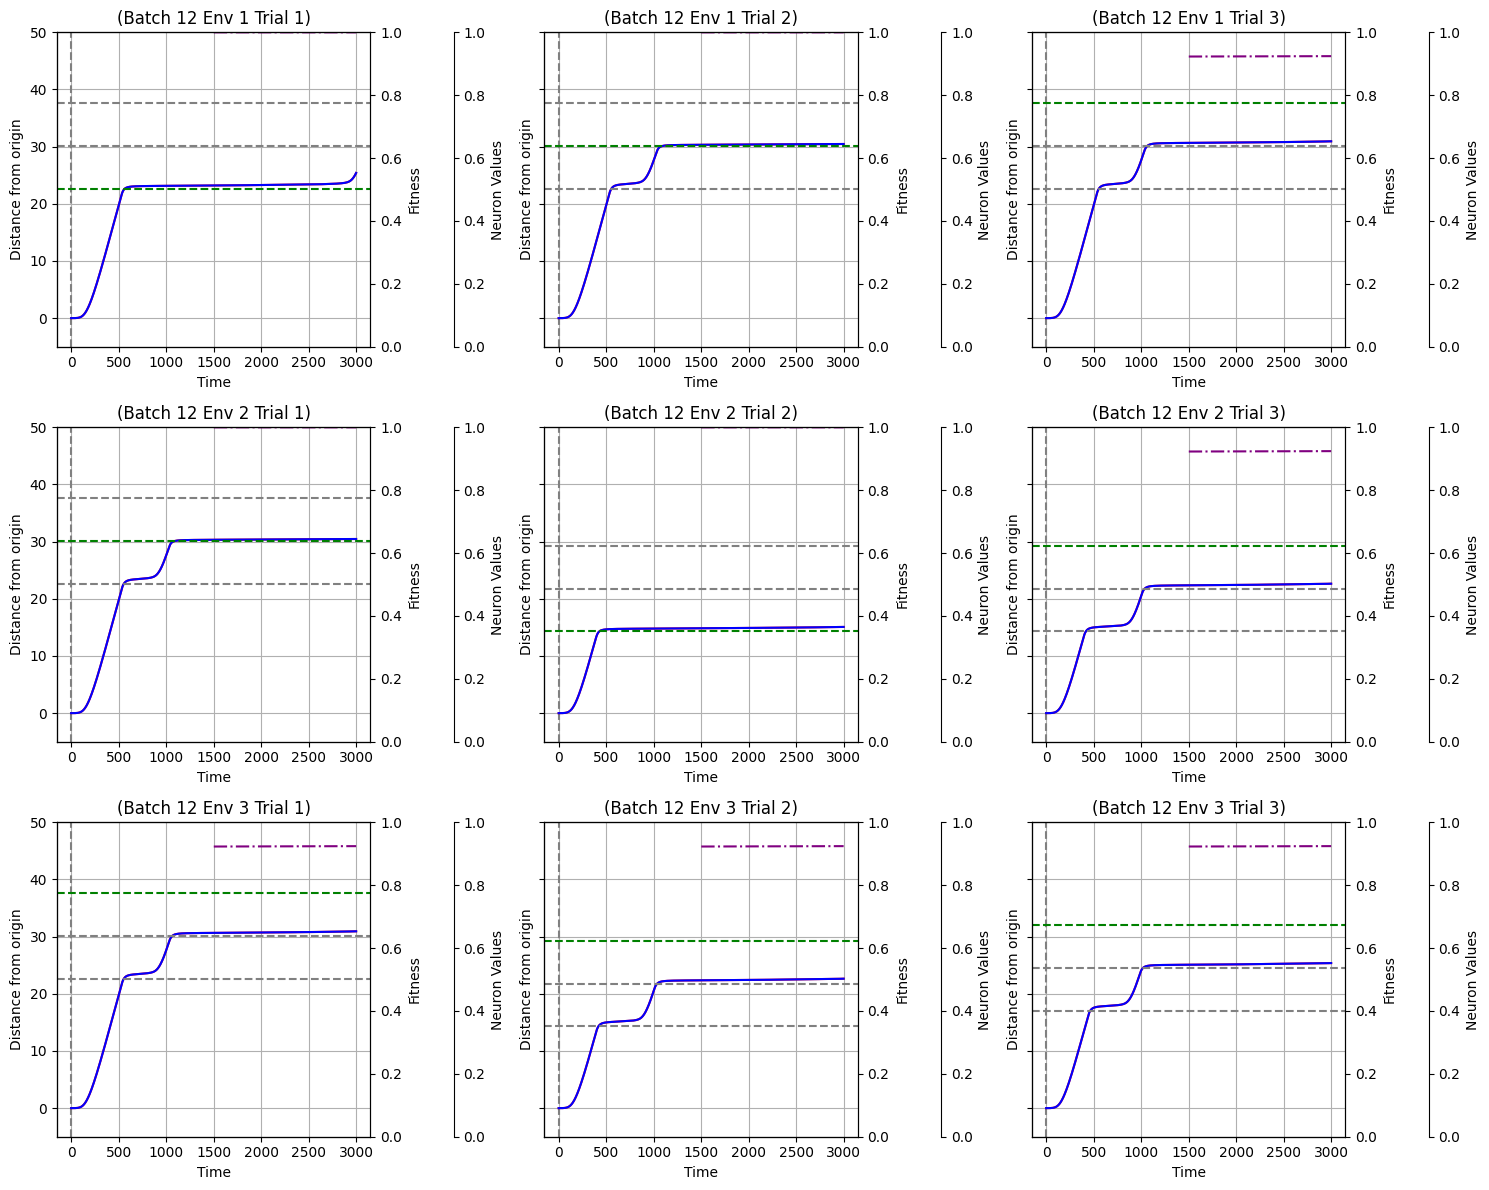

In [15]:
for batch_index, batch in enumerate(batches):
    fig, axes = plt.subplots(3, 3, figsize=(15,12), sharey=True)
    for env_index, env in enumerate(envs):        
        for trial_index, trial in enumerate(trials):
            ax = axes[env_index, trial_index]
            ax2 = ax.twinx()
            ax3 = ax.twinx()

            # Move third axis further right
            ax3.spines["right"].set_position(("outward", 60))

            # Prevent frame overlap
            ax3.set_frame_on(True)
            ax3.patch.set_visible(False)
  
            combined_signaller = []
            combined_receiver = []

            fitness_combined = []

            
            offset = 0

            for stage in stages:
                overall_evolution_dir_signaller = result_dir + f"batch_{batch}/run_{run}/behavior_Signaller_{stage}_{run}.dat"
                overall_evolution_dir_receiver = result_dir + f"batch_{batch}/run_{run}/behavior_Reciever_{stage}_{run}.dat"
                fitness_file = result_dir+ f"batch_{batch}/run_{run}/fitness_{stage}_{run}.dat"
                
                signaler = read_ith_line(trial*env, overall_evolution_dir_signaller)
                receiver = read_ith_line(trial*env, overall_evolution_dir_receiver)
                fitness = read_ith_line(trial*env, fitness_file)

                ax.axvline(offset, linestyle="--", label=f"{stage}", color="grey")

                stage_length = len(signaler)
                fitness_length = len(fitness)

                fitness_start = offset + (stage_length - fitness_length)
                fitness_end = offset + stage_length
                fitness_x = range(fitness_start, fitness_end)

                ax2.plot(fitness_x, fitness, linestyle="dashdot", color="purple")
                

                # combined_signaller.extend(signaller)
                combined_signaller.extend(signaler)
                combined_receiver.extend(receiver)

                offset += stage_length

            x_sig = list(range(0, len(combined_signaller)))
            x_rec = list(range(0, len(combined_receiver)))

            # plot the signaller and receiver
            ax.plot(x_sig, combined_receiver, label=f"Signaller", color="red")
            ax.plot(x_rec, combined_receiver, label=f"Receiver", color="blue")

            landmark_file = result_dir+ f"batch_{batch}/run_{run}/landmark_location_stage2_{run}.dat"
            landmark = read_ith_line(trial*env, landmark_file)

            # plot the line marking the landmark position

            food = landmark[3]

            landmarks = [0,1,2]
            for i in landmarks:
                if (landmark[i] != food):
                    ax.axhline(y=landmark[i], linestyle="--", label="food position", color="grey")


            ax.axhline(y=food, linestyle="--", label="food position", color="green")



            # # get the neural states
            # neural_state_1_file = result_dir+ f"batch_{batch}/run_{run}/signaller_neuron1_{stage}_0.dat"
            # neural_state_2_file = result_dir+ f"batch_{batch}/run_{run}/signaller_neuron2_{stage}_0.dat"
            # neural_state_3_file = result_dir+ f"batch_{batch}/run_{run}/signaller_neuron3_{stage}_0.dat"
            
            # neuron1 = read_ith_line(trial*env, neural_state_1_file)
            # neuron2 = read_ith_line(trial*env, neural_state_2_file)
            # neuron3 = read_ith_line(trial*env, neural_state_3_file)

            # motor = []

            # for p in range(len(neuron1)):
            #     motor.append(neuron2[p]-neuron1[p])


            ax.set_xlabel("Time")
            ax.set_ylabel("Distance from origin")
            ax.set_ylim(bottom=-5, top=50)
            ax2.set_ylim(bottom=0, top=1)
            ax2.set_ylabel("Fitness")

            ax3.set_ylabel("Neuron Values")

            ax.set_title(f"(Batch {batch} Env {env} Trial {trial})")
            ax.grid(True)
            


            fig.tight_layout()
            fig.show()